# EXO-200 v1 Transformer Results

Loads completed artifacts only. This notebook does not load HDF5 data, train models, or rerun inference. Higher ROC-AUC is better.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

configured_root = os.environ.get('EXO200_TRANSFORMER_PROJECT_ROOT')
candidate_roots = []
if configured_root:
    candidate_roots.append(Path(configured_root).expanduser())
candidate_roots.extend([
    Path.cwd() / 'exo200_detector', Path.cwd(),
    Path.cwd().parent / 'exo200_detector', Path.cwd().parent,
    Path.cwd().parent.parent / 'exo200_detector',
])
PROJECT_ROOT = next(
    (candidate.resolve() for candidate in candidate_roots
     if (candidate / 'exo_transformer').is_dir()
     and (candidate / 'exobench').is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Could not locate exo200_detector; set EXO200_TRANSFORMER_PROJECT_ROOT.'
    )
OUTPUT_ROOT = Path(os.environ.get(
    'EXO200_OUTPUT_ROOT',
    str(PROJECT_ROOT / 'results' / 'transformer_official_v1'),
)).expanduser()
print('Reading results from:', OUTPUT_ROOT)

Reading results from: /home/klz/Data/zeronu_benchmark/Transformer_Approach/exo200_detector/results/transformer_official_v1


In [2]:
EXPECTED_RUNS = [
    f'classification__{tokenization}__{position_encoding}'
    for tokenization in ('raw_patches', 'segment_summary', 'pulse_entities')
    for position_encoding in ('coordinate_mlp', 'fourier_coordinates', 'rope')
]

def load_completed_runs(output_root):
    rows = []
    for run_id in EXPECTED_RUNS:
        path = output_root / run_id / 'run_summary.json'
        if path.is_file():
            rows.append(json.loads(path.read_text(encoding='utf-8')))
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(
        ['test_auc', 'best_validation_auc'], ascending=False
    ).reset_index(drop=True)

results = load_completed_runs(OUTPUT_ROOT)
completed = set(results['run_id']) if not results.empty else set()
status = pd.DataFrame({
    'run_id': EXPECTED_RUNS,
    'status': ['complete' if run_id in completed else 'incomplete'
               for run_id in EXPECTED_RUNS],
})
print(f'Completed: {len(completed)} / {len(EXPECTED_RUNS)}')
display(status)

Completed: 9 / 9


,run_id,status
0,classification__raw_patches__coordinate_mlp,complete
1,classification__raw_patches__fourier_coordinates,complete
2,classification__raw_patches__rope,complete
3,classification__segment_summary__coordinate_mlp,complete
4,classification__segment_summary__fourier_coord...,complete
5,classification__segment_summary__rope,complete
6,classification__pulse_entities__coordinate_mlp,complete
7,classification__pulse_entities__fourier_coordi...,complete
8,classification__pulse_entities__rope,complete


In [3]:
if results.empty:
    print('No completed EXO-200 Transformer runs yet.')
else:
    columns = [
        'tokenization', 'position_encoding',
        'best_validation_auc', 'test_auc', 'test_accuracy',
        'best_epoch', 'epochs_completed', 'minutes_per_epoch',
        'parameter_count', 'test_events',
    ]
    display(results[columns].style.format({
        'best_validation_auc': '{:.6f}',
        'test_auc': '{:.6f}',
        'test_accuracy': '{:.6f}',
        'minutes_per_epoch': '{:.3f}',
        'parameter_count': '{:,.0f}',
        'test_events': '{:,.0f}',
    }))

,tokenization,position_encoding,best_validation_auc,test_auc,test_accuracy,best_epoch,epochs_completed,minutes_per_epoch,parameter_count,test_events
0,raw_patches,fourier_coordinates,0.979691,0.977804,0.929607,39,44,4.702,"125,377","140,383"
1,raw_patches,rope,0.978195,0.976599,0.927584,34,39,9.538,"116,161","140,383"
2,raw_patches,coordinate_mlp,0.976098,0.974123,0.922704,43,48,4.913,"120,769","140,383"
3,segment_summary,fourier_coordinates,0.970057,0.967887,0.906157,49,50,4.845,"116,033","140,383"
4,segment_summary,rope,0.967085,0.964940,0.901106,49,50,4.269,"106,817","140,383"
5,pulse_entities,fourier_coordinates,0.962490,0.959620,0.892437,44,49,26.786,"115,905","140,383"
6,segment_summary,coordinate_mlp,0.961995,0.959483,0.892273,38,43,4.751,"111,425","140,383"
7,pulse_entities,rope,0.962209,0.958720,0.892266,49,50,4.359,"106,689","140,383"
8,pulse_entities,coordinate_mlp,0.959001,0.954116,0.883348,46,50,13.491,"111,297","140,383"


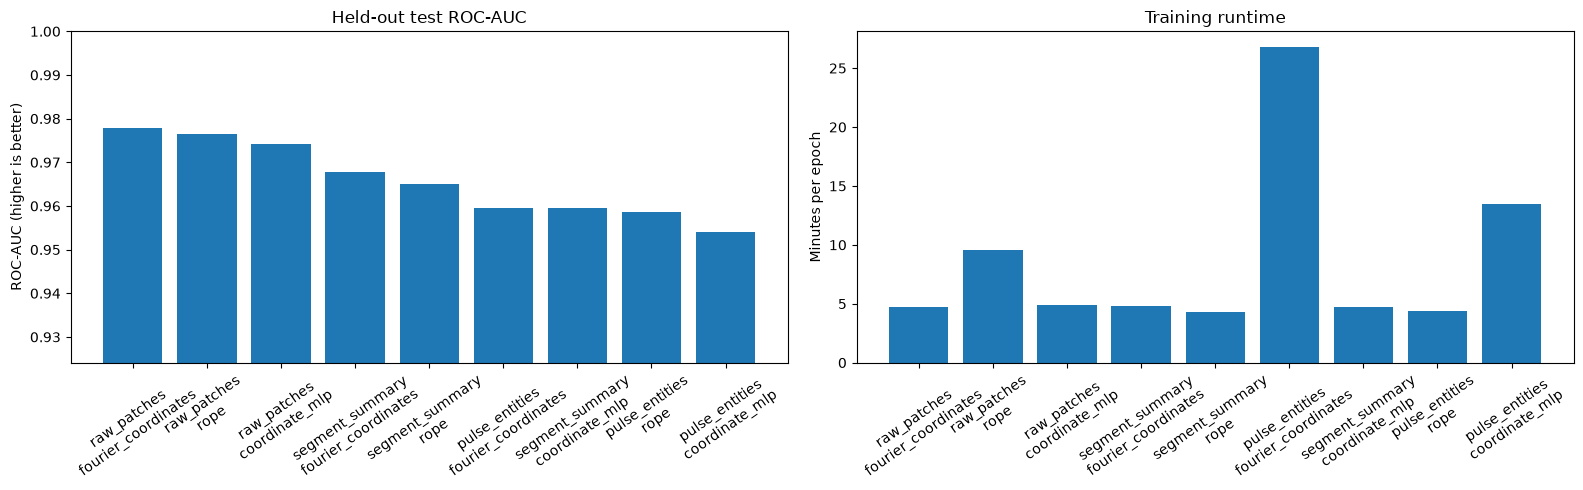

In [4]:
if not results.empty:
    plot_data = results.copy()
    plot_data['representation'] = (
        plot_data['tokenization'] + '\n' + plot_data['position_encoding']
    )
    figure, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].bar(plot_data['representation'], plot_data['test_auc'])
    axes[0].set_title('Held-out test ROC-AUC')
    axes[0].set_ylabel('ROC-AUC (higher is better)')
    axes[0].tick_params(axis='x', rotation=35)
    axes[0].set_ylim(max(0.0, plot_data['test_auc'].min() - 0.03), 1.0)

    axes[1].bar(plot_data['representation'], plot_data['minutes_per_epoch'])
    axes[1].set_title('Training runtime')
    axes[1].set_ylabel('Minutes per epoch')
    axes[1].tick_params(axis='x', rotation=35)
    figure.tight_layout()
    plt.show()

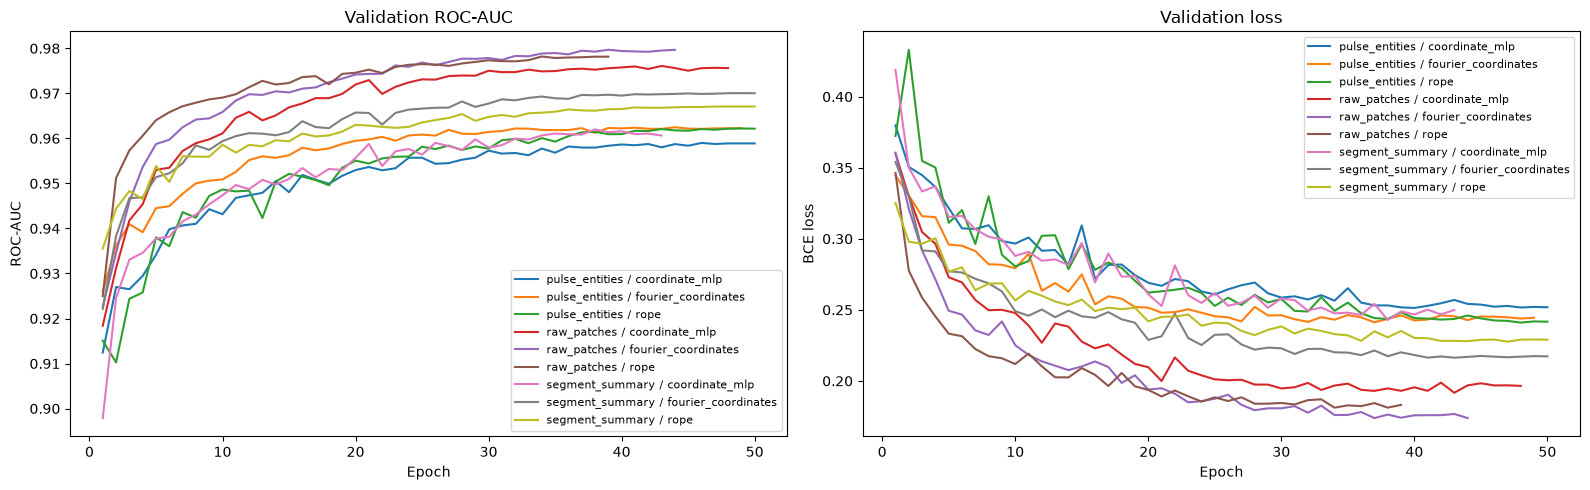

In [5]:
history_rows = []
for run_id in EXPECTED_RUNS:
    history_path = OUTPUT_ROOT / run_id / 'history.json'
    config_path = OUTPUT_ROOT / run_id / 'run_config.json'
    if not history_path.is_file() or not config_path.is_file():
        continue
    history = json.loads(history_path.read_text(encoding='utf-8'))
    config = json.loads(config_path.read_text(encoding='utf-8'))
    representation = config['representation']
    label = (
        representation['tokenization']['tokenization'] + ' / ' +
        representation['position_encoding']
    )
    for row in history:
        history_rows.append({
            'run_id': run_id,
            'label': label,
            'epoch': row['epoch'],
            'train_loss': row['train_loss'],
            'validation_loss': row['validation_loss'],
            'validation_auc': row['validation_metrics']['auc'],
        })

history_table = pd.DataFrame(history_rows)
if history_table.empty:
    print('No training histories available.')
else:
    figure, axes = plt.subplots(1, 2, figsize=(16, 5))
    for label, group in history_table.groupby('label'):
        axes[0].plot(group['epoch'], group['validation_auc'], label=label)
        axes[1].plot(group['epoch'], group['validation_loss'], label=label)
    axes[0].set(title='Validation ROC-AUC', xlabel='Epoch', ylabel='ROC-AUC')
    axes[1].set(title='Validation loss', xlabel='Epoch', ylabel='BCE loss')
    axes[0].legend(fontsize=8)
    axes[1].legend(fontsize=8)
    figure.tight_layout()
    plt.show()